In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, classification_report)

In [3]:
df = pd.read_csv('diabetes_cleaned.csv')

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [15]:
le_gender = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [16]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [17]:
le_smokinghistory = LabelEncoder()
df['smoking_history'] = le_smokinghistory.fit_transform(df['smoking_history'])

In [18]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [19]:
joblib.dump(le_gender, 'le_gender.pkl')
joblib.dump(le_smokinghistory, 'le_smoke.pkl')

['le_smoke.pkl']

In [20]:
X = df.drop('diabetes', axis = 1)
y = df['diabetes']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [25]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.fit_transform(X_test)
joblib.dump(ss, 'standard_scaler.pkl')

['standard_scaler.pkl']

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Support Vector Machine': SVC(class_weight='balanced', probability=True),
    'XGBoost': XGBClassifier(random_state = 42, eval_metric = 'logloss')
}

In [27]:
result = []

In [29]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    result.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(result).sort_values("F1 Score", ascending=False)
print(results_df)

                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2           Random Forest   0.97000   0.942122  0.689412  0.796196  0.964048
4                 XGBoost   0.96950   0.966610  0.664118  0.787308  0.967965
1           Decision Tree   0.95465   0.730389  0.739412  0.734873  0.857478
3  Support Vector Machine   0.89650   0.446961  0.917059  0.601002  0.968810
0     Logistic Regression   0.88705   0.421993  0.889412  0.572402  0.962463


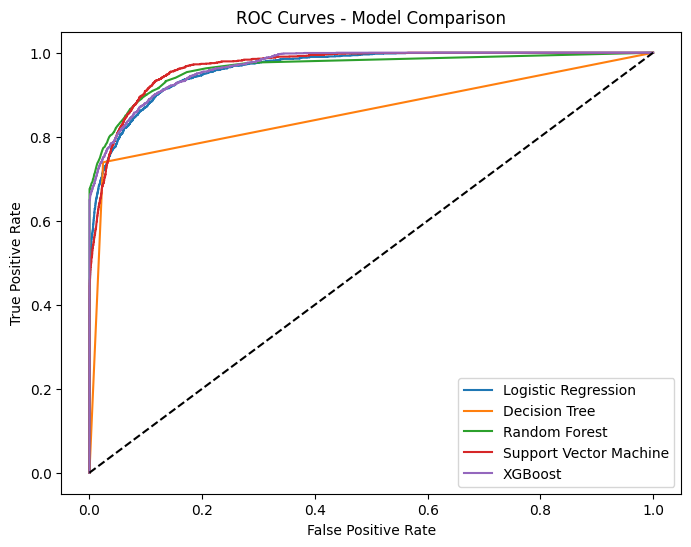

In [31]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()

In [32]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                     param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [34]:
joblib.dump(best_model, "diabetes_rf.pkl")

['diabetes_rf.pkl']

In [36]:
heart = pd.read_csv("heart_cleaned.csv")
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [37]:
X_h = heart.drop('target', axis=1)
y_h = heart['target']

In [39]:
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h)

In [40]:
scaler_heart = StandardScaler()
X_h_train_scaled = scaler_heart.fit_transform(X_h_train)
X_h_test_scaled = scaler_heart.transform(X_h_test)
joblib.dump(scaler_heart, "scaler_heart.pkl")

['scaler_heart.pkl']

In [42]:
models_heart = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [43]:
results_heart = []
for name, model in models_heart.items():
    model.fit(X_h_train_scaled, y_h_train)
    y_pred = model.predict(X_h_test_scaled)
    y_proba = model.predict_proba(X_h_test_scaled)[:, 1]

    results_heart.append({
        "Model": name,
        "Accuracy": accuracy_score(y_h_test, y_pred),
        "Precision": precision_score(y_h_test, y_pred),
        "Recall": recall_score(y_h_test, y_pred),
        "F1 Score": f1_score(y_h_test, y_pred),
        "ROC-AUC": roc_auc_score(y_h_test, y_proba)
    })

results_heart_df = pd.DataFrame(results_heart).sort_values("F1 Score", ascending=False)
print(results_heart_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.803279   0.838710  0.787879  0.812500  0.874459
0  Logistic Regression  0.786885   0.794118  0.818182  0.805970  0.873377
1        Decision Tree  0.770492   0.806452  0.757576  0.781250  0.771645
3                  SVM  0.754098   0.764706  0.787879  0.776119  0.836580
4              XGBoost  0.721311   0.735294  0.757576  0.746269  0.832251


In [44]:
best_heart_model = models_heart["Random Forest"]
joblib.dump(best_heart_model, "heart_rf.pkl")

['heart_rf.pkl']

In [46]:
kidney = pd.read_csv("kidney_cleaned.csv")
kidney.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target,Target_Binary
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease,0
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk,1
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease,0
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease,0
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease,0


In [47]:
binary_cols = [
    'Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine',
    'Bacteria in urine', 'Hypertension (yes/no)', 'Diabetes mellitus (yes/no)',
    'Coronary artery disease (yes/no)', 'Appetite (good/poor)', 'Pedal edema (yes/no)',
    'Anemia (yes/no)', 'Family history of chronic kidney disease', 'Smoking status',
    'Urinary sediment microscopy results'
]

kidney_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    kidney[col] = le.fit_transform(kidney[col])
    kidney_encoders[col] = le

In [48]:
le_activity = LabelEncoder()
kidney['Physical activity level'] = le_activity.fit_transform(kidney['Physical activity level'])
kidney_encoders['Physical activity level'] = le_activity

In [49]:
joblib.dump(kidney_encoders, "kidney_encoders.pkl")

['kidney_encoders.pkl']

In [50]:
X_k = kidney.drop(['Target', 'Target_Binary'], axis=1)
y_k = kidney['Target_Binary']


In [54]:
X_k_train, X_k_test, y_k_train, y_k_test = train_test_split(
    X_k, y_k, test_size=0.2, random_state=42, stratify=y_k
)

In [55]:
models_kidney = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [57]:
results_kidney = []
for name, model in models_kidney.items():
    model.fit(X_k_train, y_k_train)
    y_pred = model.predict(X_k_test)
    y_proba = model.predict_proba(X_k_test)[:, 1]

    results_kidney.append({
        "Model": name,
        "Accuracy": accuracy_score(y_k_test, y_pred),
        "Precision": precision_score(y_k_test, y_pred),
        "Recall": recall_score(y_k_test, y_pred),
        "F1 Score": f1_score(y_k_test, y_pred),
        "ROC-AUC": roc_auc_score(y_k_test, y_proba)
    })

results_kidney_df = pd.DataFrame(results_kidney).sort_values("F1 Score", ascending=False)
print(results_kidney_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.503408   0.195706  0.477467  0.277620  0.494215
3                  SVM  0.591042   0.196037  0.337393  0.247986  0.489742
1        Decision Tree  0.685005   0.208385  0.205847  0.207108  0.505266
4              XGBoost  0.785784   0.207921  0.025579  0.045553  0.501174
2        Random Forest  0.800146   0.000000  0.000000  0.000000  0.481821


In [58]:
best_kidney_model = models_kidney["Random Forest"]
joblib.dump(best_kidney_model, "kidney_rf.pkl")

['kidney_rf.pkl']